In [1]:
# pip install pandas matplotlib seaborn statsmodels pandas scikit-posthocs autorank
import os
import re
import ast
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy.stats import friedmanchisquare
import scikit_posthocs as sp
import polaris as po

# Reset matplotlib to default settings to avoid custom matplotlibrc issues
plt.rcdefaults()

/home/jackson/miniforge3/envs/chemeleon/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/jackson/miniforge3/envs/chemeleon/lib/python3.12/site-packages/authlib/integrations/httpx_client/assertion_client.py:5: AuthlibDeprecationWarning: The httpx module is deprecated; please use httpx2 instead.
  from ._compat import httpx2


In [2]:
# Step 1: Load all dictionaries from markdown files
results = []

for filepath in Path("polaris_results").glob("*.md"):
    model_name = os.path.splitext(os.path.basename(filepath))[0]
    with open(filepath, "r") as f:
        content = f.read()
    dicts = re.findall(r"results_dict\s*=\s*({.*?})", content, re.DOTALL)
    for d in dicts:
        parsed = ast.literal_eval(d)
        for benchmark, score in parsed.items():
            results.append({
                "model": model_name,
                "benchmark": benchmark,
                "score": score
            })

df = pd.DataFrame(results)

In [3]:
sizes, metrics = {}, {}

In [4]:
%%capture
for benchmark_name in df["benchmark"].unique():
    benchmark = po.load_benchmark(benchmark_name)
    sizes[benchmark_name] = benchmark.n_train_datapoints
    metrics[benchmark_name] = benchmark.main_metric

In [5]:
df = df[df["model"].isin({"MiniCheMeleon", "CheMeleon", "Chemprop", "fastprop", "RF", "RF_Mordred", "minimol", "MoLFormer", "MolCLR"})]

In [6]:
df = df.sort_values("benchmark", key=lambda names: [sizes[name] for name in names], ascending=False)

In [7]:
outdir = Path("hsd_subset")
outdir.mkdir(exist_ok=True)

In [8]:
df.to_csv(outdir / "source_data.csv", index=False)

,model,win count,win rate (%)
0,CheMeleon,21,75.0
2,minimol,20,71.4
5,RF,19,67.9
1,MiniCheMeleon,18,64.3
7,RF Mordred,13,46.4
6,fastprop,10,35.7
4,Chemprop,9,32.1
8,MoLFormer,9,32.1
3,MolCLR,4,14.3


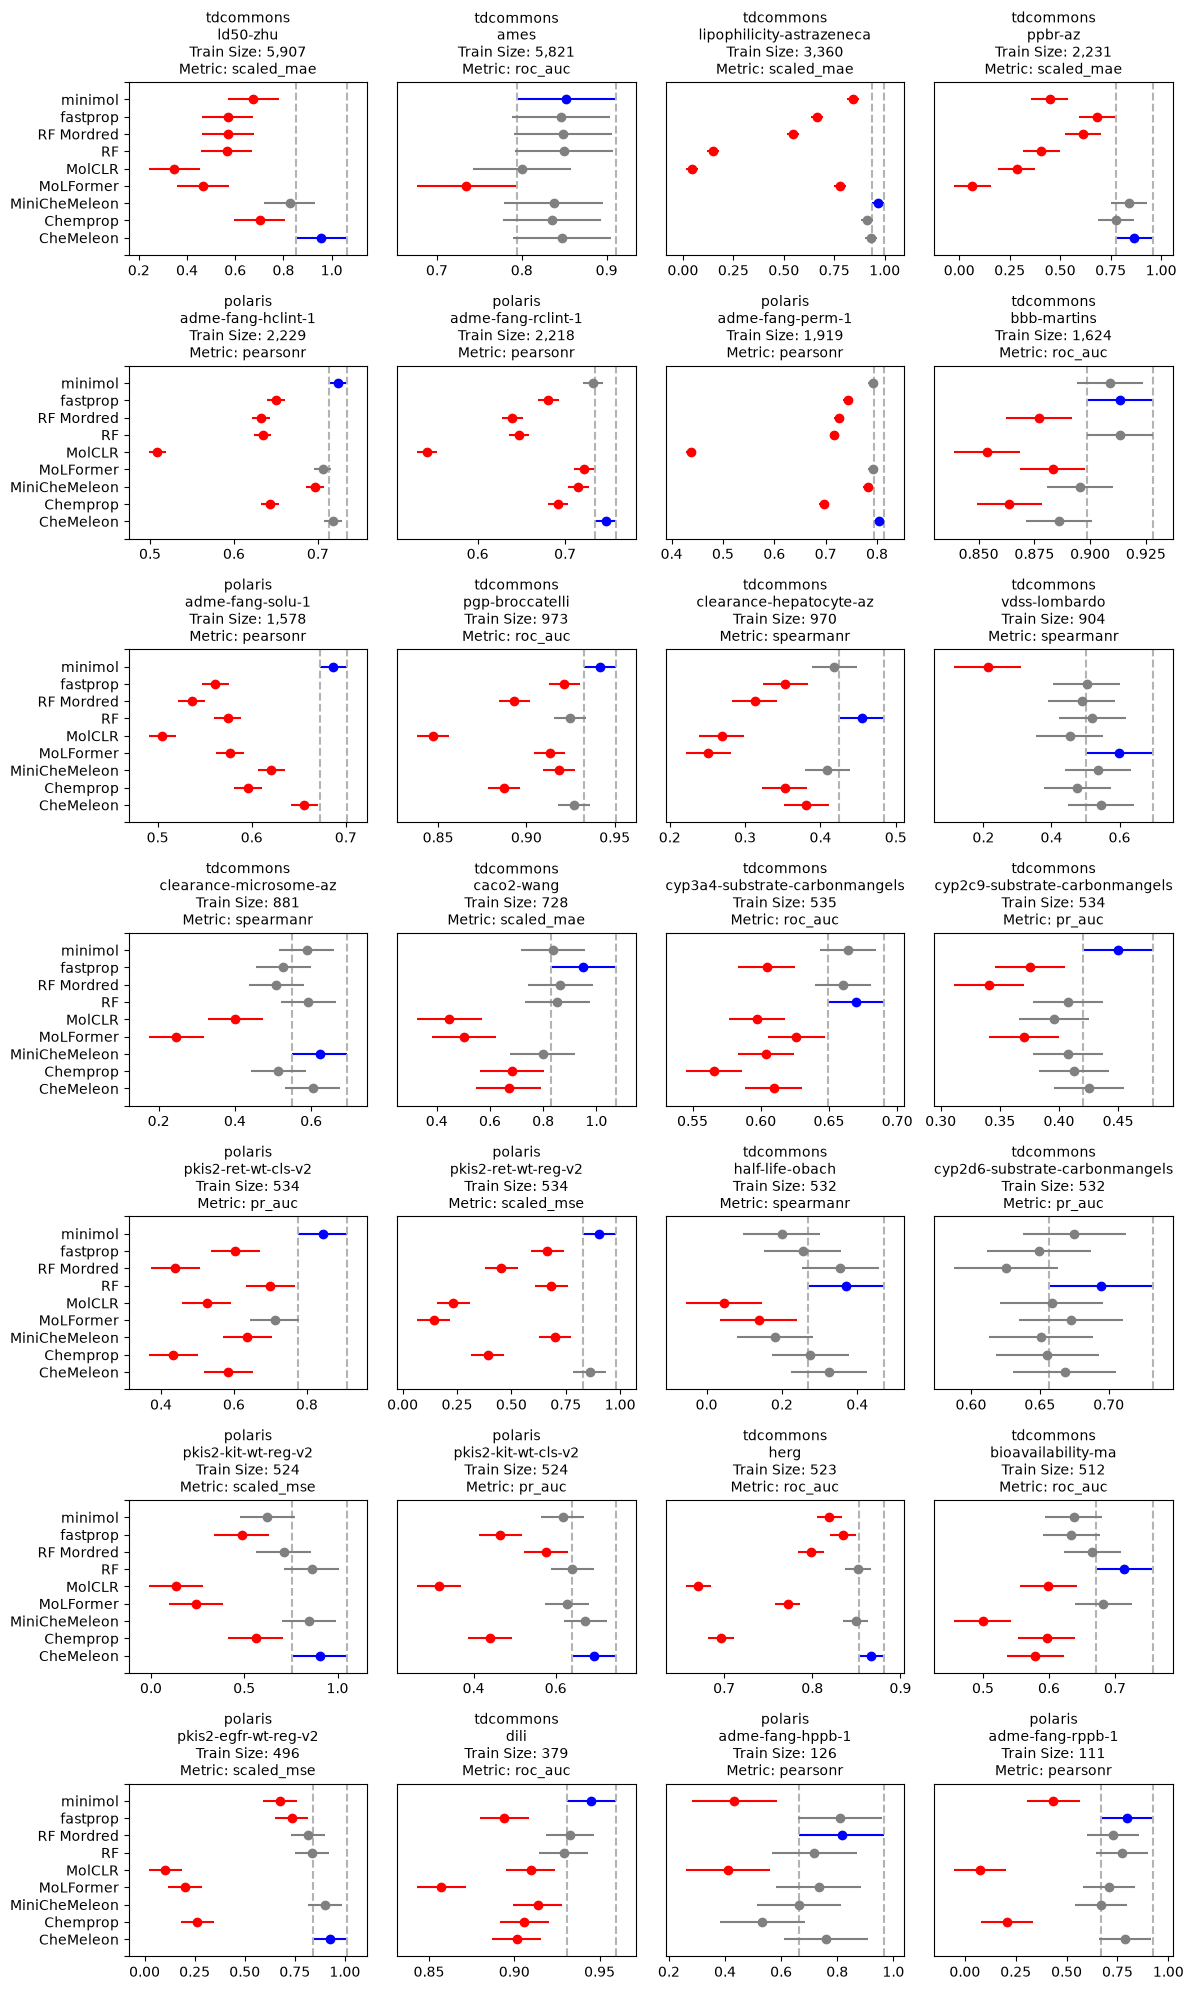

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from collections import defaultdict
from scipy.stats import rankdata

# Prepare to collect ranks
rank_tracker = defaultdict(int)
small_rank_tracker = defaultdict(int)
large_rank_tracker = defaultdict(int)

SMALL_LARGE_CUTOFF = 600

# Step 2: Group by benchmark, perform Tukey HSD, and collect plotting info
benchmark_groups = df.groupby("benchmark", sort=False)
n_benchmarks = len(benchmark_groups)

ncols = 4
nrows = int(np.ceil(n_benchmarks / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols)
axes = axes.flatten()

for i, (benchmark, bench_df) in enumerate(benchmark_groups):
    ax = axes[i]
    metric_name = metrics[benchmark].label
    if metric_name in {'mean_squared_error', 'mean_absolute_error'}:
        bench_df["score"] = (bench_df["score"].max() - bench_df["score"]) / (bench_df["score"].max() - bench_df["score"].min())
        metric_name = 'scaled_' + ('mse' if metric_name == 'mean_squared_error' else "mae")
    
    # Run Tukey HSD
    tukey = pairwise_tukeyhsd(bench_df["score"], bench_df["model"])
    
    # Plot Tukey HSD
    comparison_name = bench_df.groupby("model")["score"].mean().idxmax()
    tukey.plot_simultaneous(comparison_name=comparison_name, ax=ax, figsize=(12, 20))
    ax.set_title(benchmark.replace("/", "\n") + f"\nTrain Size: {sizes[benchmark]:,}\nMetric: {metric_name}", fontdict=dict(fontsize=10))
    
    # plot just the individual benchmark in a separate file
    fig_indiv, ax_indiv = plt.subplots()
    tukey.plot_simultaneous(comparison_name=comparison_name, ax=ax_indiv, figsize=(6, 4))
    ax_indiv.set_title(benchmark.replace("/", "\n") + f"\nTrain Size: {sizes[benchmark]:,}\nMetric: {metric_name}", fontsize=12)
    ax_indiv.set_yticklabels([name.get_text().replace("_", " ") for name in ax_indiv.get_yticklabels()])
    fig_indiv.tight_layout()
    fig_indiv.savefig(outdir / f"{benchmark.replace('/', '-')}_hsd.eps", dpi=300)
    plt.close(fig_indiv)  # close the figure to free memory

    # Y-axis label tweaks
    if i % ncols != 0:
        ax.set_yticklabels([])
        ax.set_yticks([])
    else:
        ax.set_yticklabels([name.get_text().replace("_", " ") for name in ax.get_yticklabels()])
    
    # increment win counter for best group of models
    rank_tracker[comparison_name] += 1
    if sizes[benchmark] < SMALL_LARGE_CUTOFF:
        small_rank_tracker[comparison_name] += 1
    else:
        large_rank_tracker[comparison_name] += 1
    for model_name in bench_df["model"].unique():
        if model_name == comparison_name:
            continue
        else:
            tukey_df = pd.DataFrame(tukey.summary()[1:], columns=[str(i) for i in tukey.summary()[0]])
            tukey_df["group1"] = tukey_df["group1"].map(str)
            tukey_df["group2"] = tukey_df["group2"].map(str)
            if tukey_df[
                ((tukey_df["group1"] == comparison_name) & (tukey_df["group2"] == model_name)) | 
                ((tukey_df["group1"] == model_name) & (tukey_df["group2"] == comparison_name))
            ]["reject"].values[0].data == False:
                rank_tracker[model_name] += 1
                if sizes[benchmark] < SMALL_LARGE_CUTOFF:
                    small_rank_tracker[model_name] += 1
                else:
                    large_rank_tracker[model_name] += 1
                continue  # no need to check the rest

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.savefig(outdir / "combined.eps", dpi=600)

results = pd.DataFrame.from_records(
    [{
        "model": model.replace("_", " "),
        "win count": win_count,
        "win rate (%)": 100 * win_count / n_benchmarks,
    } for model, win_count in rank_tracker.items()
    ]).sort_values(by="win rate (%)", axis=0, ascending=False)
results.round(1)


In [10]:
small_count = len(list(filter(lambda v: v < SMALL_LARGE_CUTOFF, sizes.values())))
large_count = n_benchmarks - small_count

In [11]:
results = pd.DataFrame.from_records(
    [{
        "model": model.replace("_", " "),
        "win count": win_count,
        f"win rate (% of {small_count})": 100 * win_count / small_count,
    } for model, win_count in small_rank_tracker.items()
    ]).sort_values(by=f"win rate (% of {small_count})", axis=0, ascending=False)
results.round(1)
print(f"{small_count} of {n_benchmarks} had <{SMALL_LARGE_CUTOFF} samples")
results

14 of 28 had <600 samples


,model,win count,win rate (% of 14)
0,RF,12,85.714286
1,minimol,10,71.428571
4,CheMeleon,10,71.428571
2,RF Mordred,9,64.285714
3,MiniCheMeleon,9,64.285714
7,MoLFormer,6,42.857143
8,fastprop,5,35.714286
5,Chemprop,4,28.571429
6,MolCLR,2,14.285714


In [12]:
results = pd.DataFrame.from_records(
    [{
        "model": model.replace("_", " "),
        "win count": win_count,
        f"win rate (% of {large_count})": 100 * win_count / large_count,
    } for model, win_count in large_rank_tracker.items()
    ]).sort_values(by=f"win rate (% of {large_count})", axis=0, ascending=False)
results.round(1)
print(f"{large_count} of {n_benchmarks} had >{SMALL_LARGE_CUTOFF} samples")
results

14 of 28 had >600 samples


,model,win count,win rate (% of 14)
0,CheMeleon,11,78.571429
2,minimol,10,71.428571
1,MiniCheMeleon,9,64.285714
5,RF,7,50.000000
4,Chemprop,5,35.714286
6,fastprop,5,35.714286
7,RF Mordred,4,28.571429
8,MoLFormer,3,21.428571
3,MolCLR,2,14.285714


In [13]:
df_2 = df[df["benchmark"].isin({
    "tdcommons/ld50-zhu",
    "polaris/adme-fang-solu-1",
    "tdcommons/caco2-wang",
    "tdcommons/herg",
    "polaris/pkis2-egfr-wt-reg-v2",
    "polaris/adme-fang-rppb-1",
    })]

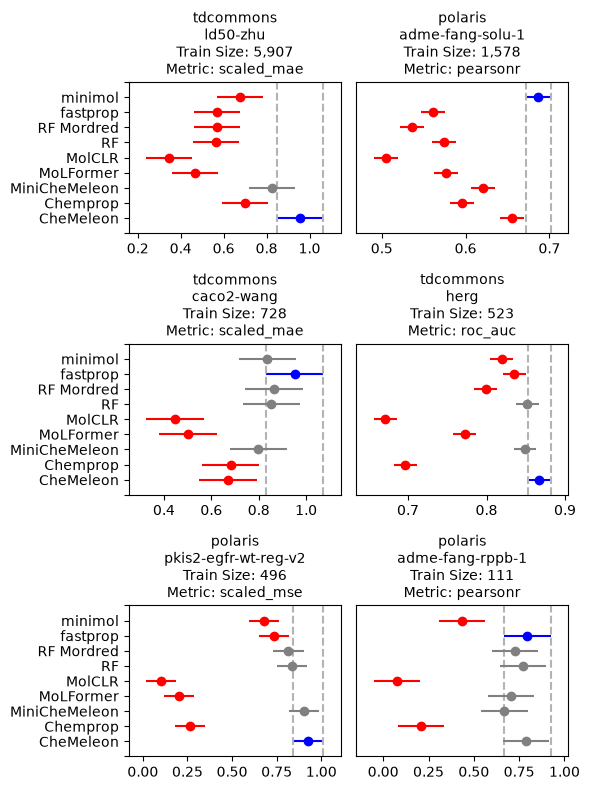

In [14]:
# Step 2: Group by benchmark, perform Tukey HSD, and collect plotting info
benchmark_groups = df_2.groupby("benchmark", sort=False)
n_benchmarks = len(benchmark_groups)

ncols = 2
nrows = int(np.ceil(n_benchmarks / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols)
axes = axes.flatten()

for i, (benchmark, bench_df) in enumerate(benchmark_groups):
    ax = axes[i]
    metric_name = metrics[benchmark].label
    if metric_name in {'mean_squared_error', 'mean_absolute_error'}:
        bench_df["score"] = (bench_df["score"].max() - bench_df["score"]) / (bench_df["score"].max() - bench_df["score"].min())
        metric_name = 'scaled_' + ('mse' if metric_name == 'mean_squared_error' else "mae")
    
    # Run Tukey HSD
    tukey = pairwise_tukeyhsd(bench_df["score"], bench_df["model"])
    
    # Plot Tukey HSD
    comparison_name = bench_df.groupby("model")["score"].mean().idxmax()
    tukey.plot_simultaneous(comparison_name=comparison_name, ax=ax, figsize=(6, 8))
    ax.set_title(benchmark.replace("/", "\n") + f"\nTrain Size: {sizes[benchmark]:,}\nMetric: {metric_name}", fontdict=dict(fontsize=10))

    # Y-axis label tweaks
    if i % ncols != 0:
        ax.set_yticklabels([])
        ax.set_yticks([])
    else:
        ax.set_yticklabels([name.get_text().replace("_", " ") for name in ax.get_yticklabels()])
    
plt.tight_layout()
plt.savefig(outdir / "combined_selected.eps", dpi=600)